In [1]:
# ======================================
# 05 Portfolio Generation + Interpretability - V4
# ======================================
#
# Purpose:
# --------
# Generate current Core Alpha and Convex Alpha portfolio candidates using
# the V4 model artifacts created in Notebook 03 and validated in Notebook 04.
#
# This notebook outputs CSV files containing:
#   - portfolio weights
#   - ticker/company/sector metadata
#   - model scores
#   - SHAP-based reason columns explaining why each name was selected
#
# Important:
# ----------
# This is a research project and educational prototype.
# The generated portfolios are NOT financial advice.
# Do not treat these outputs as investment recommendations.

In [2]:
# ======================================
# Setup
# ======================================

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from IPython.display import FileLink, display

# Optional SHAP import
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP imported successfully.")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed. Install with: pip install shap")

# ---- Paths ----
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

FEATURE_FILE = PROCESSED_DIR / "features_v4.parquet"
FEATURE_FAMILY_FILE = PROCESSED_DIR / "feature_families_v4.json"

CURRENT_SNAPSHOT_FILE = RAW_DIR / "current_ticker_snapshot.parquet"

V4_BACKTEST_DIR = PROCESSED_DIR / "v4_strategy_backtest"
BEST_BY_STRATEGY_FILE = V4_BACKTEST_DIR / "best_by_strategy.csv"

PORTFOLIO_OUTPUT_DIR = PROCESSED_DIR / "current_portfolios"
PORTFOLIO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INTERPRETABILITY_DIR = PROCESSED_DIR / "interpretability_v4"
INTERPRETABILITY_DIR.mkdir(parents=True, exist_ok=True)

# ---- Model artifacts from Notebook 03 ----
MODEL_FILES = {
    "shared_baseline_v4": MODEL_DIR / "lightgbm_shared_baseline_v4.joblib",
    "core_alpha_v4": MODEL_DIR / "lightgbm_core_alpha_v4.joblib",
    "convex_alpha_v4": MODEL_DIR / "lightgbm_convex_alpha_v4.joblib",
}

ISO_FILES = {
    "shared_baseline_v4": MODEL_DIR / "isotonic_shared_baseline_v4.joblib",
    "core_alpha_v4": MODEL_DIR / "isotonic_core_alpha_v4.joblib",
    "convex_alpha_v4": MODEL_DIR / "isotonic_convex_alpha_v4.joblib",
}

FEATURE_COLS_FILES = {
    "shared_baseline_v4": MODEL_DIR / "feature_cols_shared_baseline_v4.joblib",
    "core_alpha_v4": MODEL_DIR / "feature_cols_core_alpha_v4.joblib",
    "convex_alpha_v4": MODEL_DIR / "feature_cols_convex_alpha_v4.joblib",
}

# ---- Portfolio construction settings from Notebook 04 ----
PORTFOLIO_CONFIGS = {
    "core_alpha": {
        "model_name": "core_alpha_v4",
        "top_k": 20,
        "power": 0.6,
        "description": "Diversified rank-weighted Core Alpha basket",
    },
    "convex_alpha": {
        "model_name": "convex_alpha_v4",
        "top_k": 3,
        "power": 0.8,
        "description": "Concentrated right-tail Convex Alpha basket",
    },
}

DISCLAIMER = (
    "Research output only. Not financial advice. "
    "Do not treat this portfolio as an investment recommendation."
)

print("Project root:", PROJECT_ROOT)
print("Feature file:", FEATURE_FILE)
print("Portfolio output dir:", PORTFOLIO_OUTPUT_DIR)

SHAP imported successfully.
Project root: /Users/neilyejjey/stock_signal_engine_v1
Feature file: /Users/neilyejjey/stock_signal_engine_v1/data/processed/features_v4.parquet
Portfolio output dir: /Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios


In [3]:
# ======================================
# Load Features, Metadata, and Model Artifacts
# ======================================

features = pd.read_parquet(FEATURE_FILE)
features["date"] = pd.to_datetime(features["date"])
features["ticker"] = features["ticker"].astype(str).str.upper().str.strip()

with open(FEATURE_FAMILY_FILE, "r") as f:
    feature_families = json.load(f)

models = {}
calibrators = {}
feature_cols_by_model = {}

for model_name in MODEL_FILES:
    models[model_name] = joblib.load(MODEL_FILES[model_name])
    calibrators[model_name] = joblib.load(ISO_FILES[model_name])
    feature_cols_by_model[model_name] = joblib.load(FEATURE_COLS_FILES[model_name])

    print(f"Loaded {model_name}")
    print("  features:", len(feature_cols_by_model[model_name]))

# ---- Optional current snapshot metadata ----
if CURRENT_SNAPSHOT_FILE.exists():
    current_snapshot = pd.read_parquet(CURRENT_SNAPSHOT_FILE)
    current_snapshot["ticker"] = (
        current_snapshot["ticker"]
        .astype(str)
        .str.upper()
        .str.strip()
    )
    print("\nLoaded current snapshot:", current_snapshot.shape)
else:
    current_snapshot = pd.DataFrame({"ticker": features["ticker"].unique()})
    print("\nNo current snapshot found. Continuing with feature metadata only.")

print("\nFeatures shape:", features.shape)
print("Feature date range:", features["date"].min(), "to", features["date"].max())

Loaded shared_baseline_v4
  features: 22
Loaded core_alpha_v4
  features: 26
Loaded convex_alpha_v4
  features: 25

Loaded current snapshot: (503, 35)

Features shape: (1903828, 38)
Feature date range: 2010-01-04 00:00:00 to 2025-12-31 00:00:00


In [4]:
# ======================================
# Select Latest Available Feature Universe
# ======================================

as_of_date = features["date"].max()

latest_features = (
    features[features["date"] == as_of_date]
    .copy()
    .sort_values("ticker")
    .reset_index(drop=True)
)

print("As-of date:", as_of_date)
print("Latest universe shape:", latest_features.shape)
print("Tickers:", latest_features["ticker"].nunique())

latest_features.head()

As-of date: 2025-12-31 00:00:00
Latest universe shape: (503, 38)
Tickers: 503


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,sub_industry,company,core_quality_value_combo,core_stability_combo,core_momentum_quality_combo,core_defensive_value_combo,convex_momentum_value_combo,convex_momentum_vol_combo,convex_rebound_combo,convex_value_rebound_combo
0,2025-12-31,A,0.129979,0.012054,0.019837,-0.218292,26.902868,0.037171,0.713147,0.379242,...,Life Sciences Tools & Services,Agilent Technologies,1.324982,0.810899,1.440593,0.872152,1.311425,0.938124,1.343366,1.562402
1,2025-12-31,AAPL,0.282397,0.068467,0.020422,-0.050072,34.249683,0.029197,0.876494,0.477046,...,"Technology Hardware, Storage & Peripherals",Apple Inc.,1.331392,1.204371,1.358278,0.857033,1.056820,1.077844,1.071325,0.774606
2,2025-12-31,ABBV,0.216907,0.328461,0.016245,-0.058281,87.554620,0.011421,0.824701,0.800399,...,Biotechnology,AbbVie,0.741973,1.461983,1.556839,0.723106,0.913027,1.111776,1.051341,0.339268
3,2025-12-31,ABNB,0.002437,0.017506,0.023595,-0.374101,35.124070,0.028471,0.420319,0.383234,...,"Hotels, Resorts & Cruise Lines",Airbnb,0.751484,0.460340,0.945615,0.516190,0.934324,1.107784,1.235428,1.366199
4,2025-12-31,ABT,-0.057400,0.110219,0.013931,-0.094298,27.117647,0.036876,0.296813,0.560878,...,Health Care Equipment,Abbott Laboratories,1.714023,1.522331,1.742429,1.280061,1.480768,0.694611,0.640749,1.263826


In [5]:
# ======================================
# Scoring Helper Functions
# ======================================

def inverse_symmetric_log(x):
    return np.sign(x) * np.expm1(np.abs(x))


def score_universe_for_model(latest_features, model_name):
    model = models[model_name]
    iso = calibrators[model_name]
    feature_cols = feature_cols_by_model[model_name]

    missing_cols = [
        c for c in feature_cols
        if c not in latest_features.columns
    ]

    if missing_cols:
        raise ValueError(f"{model_name} missing feature columns: {missing_cols}")

    score_df = latest_features.copy()

    # Match Notebook 03 behavior: only score rows with complete selected features.
    score_df = score_df.dropna(subset=feature_cols).copy()

    X = score_df[feature_cols].copy()

    score_df["predicted_target"] = model.predict(X)
    score_df["predicted_excess_return"] = inverse_symmetric_log(
        score_df["predicted_target"]
    )
    score_df["calibrated_pred"] = iso.transform(
        score_df["predicted_excess_return"]
    )

    score_df["model_name"] = model_name

    return score_df, X


def build_rank_weighted_portfolio(scored_df, portfolio_name, top_k, power):
    selected = (
        scored_df
        .dropna(subset=["calibrated_pred"])
        .nlargest(top_k, "calibrated_pred")
        .copy()
        .reset_index(drop=True)
    )

    # Highest score gets highest rank.
    ranks = selected["calibrated_pred"].rank(method="first")
    weights = ranks ** power

    selected["weight"] = weights / weights.sum()
    selected["weight_pct"] = selected["weight"] * 100

    selected["portfolio_name"] = portfolio_name
    selected["portfolio_rank"] = selected["calibrated_pred"].rank(
        ascending=False,
        method="first",
    ).astype(int)

    selected = selected.sort_values("portfolio_rank").reset_index(drop=True)

    return selected

In [6]:
# ======================================
# Score Current Universe
# ======================================

scored_universes = {}
score_matrices = {}

for portfolio_name, config in PORTFOLIO_CONFIGS.items():
    model_name = config["model_name"]

    scored_df, X = score_universe_for_model(
        latest_features=latest_features,
        model_name=model_name,
    )

    scored_universes[portfolio_name] = scored_df
    score_matrices[portfolio_name] = X

    print(portfolio_name)
    print("  model:", model_name)
    print("  scored rows:", scored_df.shape)
    print()

core_alpha
  model: core_alpha_v4
  scored rows: (473, 42)

convex_alpha
  model: convex_alpha_v4
  scored rows: (501, 42)



In [7]:
# ======================================
# Build Current Core Alpha and Convex Alpha Portfolios
# ======================================

current_portfolios = {}

for portfolio_name, config in PORTFOLIO_CONFIGS.items():
    portfolio = build_rank_weighted_portfolio(
        scored_df=scored_universes[portfolio_name],
        portfolio_name=portfolio_name,
        top_k=config["top_k"],
        power=config["power"],
    )

    current_portfolios[portfolio_name] = portfolio

    print(portfolio_name)
    print("  model:", config["model_name"])
    print("  top_k:", config["top_k"])
    print("  weight sum:", portfolio["weight"].sum())
    print()

current_portfolios["core_alpha"][
    ["portfolio_rank", "ticker", "company", "sector", "weight_pct", "calibrated_pred"]
].head(20)

core_alpha
  model: core_alpha_v4
  top_k: 20
  weight sum: 1.0

convex_alpha
  model: convex_alpha_v4
  top_k: 3
  weight sum: 1.0



,portfolio_rank,ticker,company,sector,weight_pct,calibrated_pred
0,1,NOW,ServiceNow,Technology,7.235793,2.349578
1,2,PSKY,Paramount Skydance Corporation,Communication Services,7.474374,2.349578
2,3,VST,Vistra Corp.,Utilities,7.707981,2.349578
3,4,TSLA,"Tesla, Inc.",Consumer Cyclical,6.991848,1.897477
4,5,ANET,Arista Networks,Technology,6.486007,1.674142
5,6,ORCL,Oracle Corporation,Technology,6.742092,1.674142
6,7,AMAT,Applied Materials,Technology,4.448122,1.463344
7,8,AXON,Axon Enterprise,Industrials,4.773843,1.463344
8,9,LITE,Lumentum,Technology,5.085371,1.463344
9,10,PLTR,Palantir Technologies,Technology,5.384660,1.463344


In [8]:
# ======================================
# SHAP Reason Helper Functions
# ======================================

FEATURE_LABELS = {
    "ret_6m": "6M return",
    "ret_12m": "12M return",
    "vol_12m": "12M volatility",
    "drawdown": "drawdown",
    "pe_ratio": "P/E ratio",
    "earnings_yield": "earnings yield",
    "ret_6m_rank": "6M momentum rank",
    "ret_12m_rank": "12M momentum rank",
    "vol_12m_rank": "volatility rank",
    "drawdown_rank": "stability / low-drawdown rank",
    "drawdown_severity_rank": "drawdown severity rank",
    "low_vol_rank": "low-volatility rank",
    "momentum_vol_adj": "volatility-adjusted momentum",
    "momentum_composite": "momentum composite",
    "quality_value_combo": "quality/value composite",
    "earnings_yield_rank": "earnings yield rank",
    "pe_cheap_rank": "cheap P/E rank",
    "sector_earnings_yield_rank": "sector-relative earnings yield",
    "sector_pe_cheap_rank": "sector-relative cheap P/E",
    "valuation_rank_combo": "valuation composite",
    "sector_valuation_rank_combo": "sector-relative valuation composite",
    "quality_value_combo_ranked": "ranked quality/value composite",
    "core_quality_value_combo": "Core quality/value composite",
    "core_stability_combo": "Core stability composite",
    "core_momentum_quality_combo": "Core momentum/quality composite",
    "core_defensive_value_combo": "Core defensive value composite",
    "convex_momentum_value_combo": "Convex momentum/value composite",
    "convex_momentum_vol_combo": "Convex momentum/volatility composite",
    "convex_rebound_combo": "Convex rebound composite",
    "convex_value_rebound_combo": "Convex value/rebound composite",
}


def nice_feature_name(feature):
    return FEATURE_LABELS.get(feature, feature)


def format_feature_value(value):
    if pd.isna(value):
        return "NA"

    if isinstance(value, (int, np.integer)):
        return str(value)

    if abs(value) >= 100:
        return f"{value:,.2f}"

    if abs(value) >= 1:
        return f"{value:.3f}"

    return f"{value:.3f}"


def shap_reason_from_row(feature_values, shap_values, feature_cols, top_n=3):
    contribution_df = pd.DataFrame({
        "feature": feature_cols,
        "feature_label": [nice_feature_name(c) for c in feature_cols],
        "feature_value": [feature_values[c] for c in feature_cols],
        "shap_value": shap_values,
    })

    positive = (
        contribution_df[contribution_df["shap_value"] > 0]
        .sort_values("shap_value", ascending=False)
        .head(top_n)
        .copy()
    )

    negative = (
        contribution_df[contribution_df["shap_value"] < 0]
        .sort_values("shap_value", ascending=True)
        .head(2)
        .copy()
    )

    positive_parts = [
        f"{row.feature_label}={format_feature_value(row.feature_value)} "
        f"(SHAP +{row.shap_value:.4f})"
        for row in positive.itertuples()
    ]

    negative_parts = [
        f"{row.feature_label}={format_feature_value(row.feature_value)} "
        f"(SHAP {row.shap_value:.4f})"
        for row in negative.itertuples()
    ]

    reason = "Positive drivers: " + "; ".join(positive_parts)

    if negative_parts:
        reason += " | Watchouts: " + "; ".join(negative_parts)

    return reason, positive, negative

In [9]:
# ======================================
# Add SHAP Reasons to Current Portfolios
# ======================================

if not SHAP_AVAILABLE:
    raise ImportError("SHAP is required for portfolio reason columns. Run: pip install shap")

portfolio_outputs = {}
portfolio_shap_details = {}

for portfolio_name, portfolio in current_portfolios.items():
    config = PORTFOLIO_CONFIGS[portfolio_name]
    model_name = config["model_name"]

    model = models[model_name]
    feature_cols = feature_cols_by_model[model_name]

    explainer = shap.TreeExplainer(model)

    # Build X for selected holdings only.
    selected_features = portfolio[["date", "ticker"]].merge(
        latest_features[["date", "ticker"] + feature_cols],
        on=["date", "ticker"],
        how="left",
    )

    X_selected = selected_features[feature_cols].copy()

    shap_values = explainer.shap_values(X_selected)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    output = portfolio.copy()
    reasons = []
    top_positive_features = []
    top_negative_features = []

    detail_rows = []

    for i in range(len(output)):
        feature_values = X_selected.iloc[i]
        shap_row = shap_values[i]

        reason, positive, negative = shap_reason_from_row(
            feature_values=feature_values,
            shap_values=shap_row,
            feature_cols=feature_cols,
            top_n=3,
        )

        reasons.append(reason)
        top_positive_features.append(", ".join(positive["feature"].tolist()))
        top_negative_features.append(", ".join(negative["feature"].tolist()))

        for row in positive.itertuples():
            detail_rows.append({
                "portfolio_name": portfolio_name,
                "ticker": output.loc[i, "ticker"],
                "company": output.loc[i, "company"] if "company" in output.columns else np.nan,
                "driver_type": "positive",
                "feature": row.feature,
                "feature_label": row.feature_label,
                "feature_value": row.feature_value,
                "shap_value": row.shap_value,
            })

        for row in negative.itertuples():
            detail_rows.append({
                "portfolio_name": portfolio_name,
                "ticker": output.loc[i, "ticker"],
                "company": output.loc[i, "company"] if "company" in output.columns else np.nan,
                "driver_type": "negative",
                "feature": row.feature,
                "feature_label": row.feature_label,
                "feature_value": row.feature_value,
                "shap_value": row.shap_value,
            })

    output["reason"] = reasons
    output["top_positive_features"] = top_positive_features
    output["top_negative_features"] = top_negative_features

    output["as_of_date"] = as_of_date
    output["strategy_description"] = config["description"]
    output["model_used"] = model_name
    output["not_financial_advice"] = DISCLAIMER

    portfolio_outputs[portfolio_name] = output
    portfolio_shap_details[portfolio_name] = pd.DataFrame(detail_rows)

    print(portfolio_name, "complete:", output.shape)

core_alpha complete: (20, 53)
convex_alpha complete: (3, 53)


In [10]:
# ======================================
# Add Current Snapshot Metadata
# ======================================

snapshot_cols = [
    "ticker",
    "current_market_cap",
    "current_shares_outstanding",
    "current_float_shares",
    "beta",
    "current_trailing_pe",
    "current_forward_pe",
    "current_price_to_book",
    "current_enterprise_value",
    "current_ev_to_revenue",
    "current_ev_to_ebitda",
    "current_profit_margin",
    "current_operating_margin",
    "current_gross_margin",
    "current_revenue_growth",
    "current_earnings_growth",
    "current_recommendation_mean",
    "current_recommendation_key",
    "current_num_analyst_opinions",
    "current_target_mean_price",
    "current_dividend_yield",
    "currency",
    "exchange",
    "snapshot_date",
]

snapshot_cols = [c for c in snapshot_cols if c in current_snapshot.columns]

for portfolio_name, output in portfolio_outputs.items():
    if snapshot_cols:
        output = output.merge(
            current_snapshot[snapshot_cols].drop_duplicates("ticker"),
            on="ticker",
            how="left",
        )

    portfolio_outputs[portfolio_name] = output

portfolio_outputs["convex_alpha"].head()

,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,current_revenue_growth,current_earnings_growth,current_recommendation_mean,current_recommendation_key,current_num_analyst_opinions,current_target_mean_price,current_dividend_yield,currency,exchange,snapshot_date
0,2025-12-31,PSKY,0.050407,0.307920,0.037387,-0.850215,391.333340,0.002555,0.553785,0.792415,...,0.022,-0.318,NaN,none,14.0,12.64286,2.03,USD,NMS,2026-07-01
1,2025-12-31,TPL,-0.193302,-0.242913,0.030349,-0.498368,60.628407,0.016494,0.079681,0.075848,...,0.208,0.183,NaN,none,2.0,445.00000,0.55,USD,NYQ,2026-07-01
2,2025-12-31,XYZ,-0.059665,-0.268405,0.033614,-0.769029,33.933334,0.029470,0.288845,0.061876,...,0.049,NaN,1.56818,buy,40.0,90.40400,NaN,USD,NYQ,2026-07-01


In [11]:
# ======================================
# Final Portfolio Column Selection
# ======================================

final_portfolio_outputs = {}

base_output_cols = [
    "portfolio_name",
    "as_of_date",
    "portfolio_rank",
    "ticker",
    "company",
    "sector",
    "sub_industry",
    "weight",
    "weight_pct",
    "model_used",
    "calibrated_pred",
    "predicted_excess_return",
    "predicted_target",
    "reason",
    "top_positive_features",
    "top_negative_features",

    # Current metadata, not used as historical model features.
    "current_market_cap",
    "current_forward_pe",
    "current_trailing_pe",
    "current_price_to_book",
    "beta",
    "current_revenue_growth",
    "current_earnings_growth",
    "current_profit_margin",
    "current_operating_margin",
    "current_num_analyst_opinions",
    "current_recommendation_mean",
    "current_recommendation_key",
    "current_target_mean_price",
    "current_dividend_yield",
    "currency",
    "exchange",
    "snapshot_date",

    "strategy_description",
    "not_financial_advice",
]

for portfolio_name, output in portfolio_outputs.items():
    cols = [c for c in base_output_cols if c in output.columns]

    final_output = output[cols].copy()

    final_output = final_output.sort_values(
        "portfolio_rank"
    ).reset_index(drop=True)

    final_portfolio_outputs[portfolio_name] = final_output

final_portfolio_outputs["core_alpha"]

,portfolio_name,as_of_date,portfolio_rank,ticker,company,sector,sub_industry,weight,weight_pct,model_used,...,current_num_analyst_opinions,current_recommendation_mean,current_recommendation_key,current_target_mean_price,current_dividend_yield,currency,exchange,snapshot_date,strategy_description,not_financial_advice
0,core_alpha,2025-12-31,1,NOW,ServiceNow,Technology,Systems Software,0.072358,7.235793,core_alpha_v4,...,46.0,1.43750,strong_buy,141.12239,NaN,USD,NYQ,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
1,core_alpha,2025-12-31,2,PSKY,Paramount Skydance Corporation,Communication Services,Movies & Entertainment,0.074744,7.474374,core_alpha_v4,...,14.0,NaN,none,12.64286,2.03,USD,NMS,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
2,core_alpha,2025-12-31,3,VST,Vistra Corp.,Utilities,Electric Utilities,0.077080,7.707981,core_alpha_v4,...,18.0,1.40000,strong_buy,222.88889,0.58,USD,NYQ,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
3,core_alpha,2025-12-31,4,TSLA,"Tesla, Inc.",Consumer Cyclical,Automobile Manufacturers,0.069918,6.991848,core_alpha_v4,...,41.0,2.34043,buy,421.15610,NaN,USD,NMS,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
4,core_alpha,2025-12-31,5,ANET,Arista Networks,Technology,Communications Equipment,0.064860,6.486007,core_alpha_v4,...,27.0,1.30000,strong_buy,190.08810,NaN,USD,NYQ,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
5,core_alpha,2025-12-31,6,ORCL,Oracle Corporation,Technology,Application Software,0.067421,6.742092,core_alpha_v4,...,39.0,1.52381,buy,252.64050,1.36,USD,NYQ,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
6,core_alpha,2025-12-31,7,AMAT,Applied Materials,Technology,Semiconductor Materials & Equipment,0.044481,4.448122,core_alpha_v4,...,35.0,1.48718,strong_buy,578.91430,0.29,USD,NMS,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
7,core_alpha,2025-12-31,8,AXON,Axon Enterprise,Industrials,Aerospace & Defense,0.047738,4.773843,core_alpha_v4,...,18.0,1.60000,buy,662.03780,NaN,USD,NMS,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
8,core_alpha,2025-12-31,9,LITE,Lumentum,Technology,Communications Equipment,0.050854,5.085371,core_alpha_v4,...,25.0,1.56000,buy,1111.29060,NaN,USD,NMS,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...
9,core_alpha,2025-12-31,10,PLTR,Palantir Technologies,Technology,Application Software,0.053847,5.384660,core_alpha_v4,...,27.0,1.90625,buy,182.75407,NaN,USD,NMS,2026-07-01,Diversified rank-weighted Core Alpha basket,Research output only. Not financial advice. Do...


In [12]:
# ======================================
# Save Current Portfolio CSVs + Download Links
# ======================================

as_of_str = pd.Timestamp(as_of_date).strftime("%Y%m%d")

CORE_PORTFOLIO_CSV = PORTFOLIO_OUTPUT_DIR / f"current_core_alpha_portfolio_{as_of_str}.csv"
CONVEX_PORTFOLIO_CSV = PORTFOLIO_OUTPUT_DIR / f"current_convex_alpha_portfolio_{as_of_str}.csv"

CORE_SHAP_DETAIL_CSV = PORTFOLIO_OUTPUT_DIR / f"current_core_alpha_shap_details_{as_of_str}.csv"
CONVEX_SHAP_DETAIL_CSV = PORTFOLIO_OUTPUT_DIR / f"current_convex_alpha_shap_details_{as_of_str}.csv"

final_portfolio_outputs["core_alpha"].to_csv(
    CORE_PORTFOLIO_CSV,
    index=False,
)

final_portfolio_outputs["convex_alpha"].to_csv(
    CONVEX_PORTFOLIO_CSV,
    index=False,
)

portfolio_shap_details["core_alpha"].to_csv(
    CORE_SHAP_DETAIL_CSV,
    index=False,
)

portfolio_shap_details["convex_alpha"].to_csv(
    CONVEX_SHAP_DETAIL_CSV,
    index=False,
)

print("Saved portfolio CSVs:")
print("Core:  ", CORE_PORTFOLIO_CSV)
print("Convex:", CONVEX_PORTFOLIO_CSV)

print("\nSaved SHAP detail CSVs:")
print("Core details:  ", CORE_SHAP_DETAIL_CSV)
print("Convex details:", CONVEX_SHAP_DETAIL_CSV)

print("\nDownload links:")
display(FileLink(str(CORE_PORTFOLIO_CSV)))
display(FileLink(str(CONVEX_PORTFOLIO_CSV)))
display(FileLink(str(CORE_SHAP_DETAIL_CSV)))
display(FileLink(str(CONVEX_SHAP_DETAIL_CSV)))

Saved portfolio CSVs:
Core:   /Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios/current_core_alpha_portfolio_20251231.csv
Convex: /Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios/current_convex_alpha_portfolio_20251231.csv

Saved SHAP detail CSVs:
Core details:   /Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios/current_core_alpha_shap_details_20251231.csv
Convex details: /Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios/current_convex_alpha_shap_details_20251231.csv

Download links:


/Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios/current_core_alpha_portfolio_20251231.csv

/Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios/current_convex_alpha_portfolio_20251231.csv

/Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios/current_core_alpha_shap_details_20251231.csv

/Users/neilyejjey/stock_signal_engine_v1/data/processed/current_portfolios/current_convex_alpha_shap_details_20251231.csv

In [13]:
# ======================================
# Display Core and Convex Holdings
# ======================================

core_display_cols = [
    "portfolio_rank",
    "ticker",
    "company",
    "sector",
    "weight_pct",
    "calibrated_pred",
    "reason",
]

convex_display_cols = core_display_cols.copy()

core_display_cols = [
    c for c in core_display_cols
    if c in final_portfolio_outputs["core_alpha"].columns
]

convex_display_cols = [
    c for c in convex_display_cols
    if c in final_portfolio_outputs["convex_alpha"].columns
]

print("Core Alpha Portfolio")
display(final_portfolio_outputs["core_alpha"][core_display_cols])

print("\nConvex Alpha Portfolio")
display(final_portfolio_outputs["convex_alpha"][convex_display_cols])

Core Alpha Portfolio


,portfolio_rank,ticker,company,sector,weight_pct,calibrated_pred,reason
0,1,NOW,ServiceNow,Technology,7.235793,2.349578,Positive drivers: quality/value composite=0.31...
1,2,PSKY,Paramount Skydance Corporation,Communication Services,7.474374,2.349578,Positive drivers: 12M volatility=0.037 (SHAP +...
2,3,VST,Vistra Corp.,Utilities,7.707981,2.349578,Positive drivers: 12M volatility=0.042 (SHAP +...
3,4,TSLA,"Tesla, Inc.",Consumer Cyclical,6.991848,1.897477,Positive drivers: 12M volatility=0.040 (SHAP +...
4,5,ANET,Arista Networks,Technology,6.486007,1.674142,Positive drivers: 12M volatility=0.036 (SHAP +...
5,6,ORCL,Oracle Corporation,Technology,6.742092,1.674142,Positive drivers: 12M volatility=0.039 (SHAP +...
6,7,AMAT,Applied Materials,Technology,4.448122,1.463344,Positive drivers: sector-relative earnings yie...
7,8,AXON,Axon Enterprise,Industrials,4.773843,1.463344,Positive drivers: 12M volatility=0.033 (SHAP +...
8,9,LITE,Lumentum,Technology,5.085371,1.463344,Positive drivers: 12M volatility=0.049 (SHAP +...
9,10,PLTR,Palantir Technologies,Technology,5.384660,1.463344,Positive drivers: 12M volatility=0.042 (SHAP +...



Convex Alpha Portfolio


,portfolio_rank,ticker,company,sector,weight_pct,calibrated_pred,reason
0,1,PSKY,Paramount Skydance Corporation,Communication Services,19.420018,2.667864,Positive drivers: 12M volatility=0.037 (SHAP +...
1,2,TPL,Texas Pacific Land Corporation,Energy,33.812215,2.667864,Positive drivers: quality/value composite=0.20...
2,3,XYZ,"Block, Inc.",Technology,46.767767,2.667864,Positive drivers: 12M volatility=0.034 (SHAP +...


In [14]:
# ======================================
# Native Feature Importance: Core vs Convex Models
# ======================================

importance_tables = []

for portfolio_name, config in PORTFOLIO_CONFIGS.items():
    model_name = config["model_name"]
    model = models[model_name]
    feature_cols = feature_cols_by_model[model_name]

    imp = pd.DataFrame({
        "portfolio_name": portfolio_name,
        "model_name": model_name,
        "feature": feature_cols,
        "native_importance": model.feature_importances_,
    })

    imp = imp.sort_values(
        "native_importance",
        ascending=False,
    ).reset_index(drop=True)

    importance_tables.append(imp)

native_importance_v4 = pd.concat(
    importance_tables,
    ignore_index=True,
)

native_importance_v4.to_csv(
    INTERPRETABILITY_DIR / "native_feature_importance_core_convex_v4.csv",
    index=False,
)

native_importance_v4.head(30)

,portfolio_name,model_name,feature,native_importance
0,core_alpha,core_alpha_v4,sector_earnings_yield_rank,324
1,core_alpha,core_alpha_v4,pe_ratio,279
2,core_alpha,core_alpha_v4,sector_pe_cheap_rank,242
3,core_alpha,core_alpha_v4,sector_valuation_rank_combo,151
4,core_alpha,core_alpha_v4,vol_12m,70
5,core_alpha,core_alpha_v4,quality_value_combo,63
6,core_alpha,core_alpha_v4,valuation_rank_combo,58
7,core_alpha,core_alpha_v4,pe_cheap_rank,57
8,core_alpha,core_alpha_v4,earnings_yield_rank,51
9,core_alpha,core_alpha_v4,earnings_yield,47


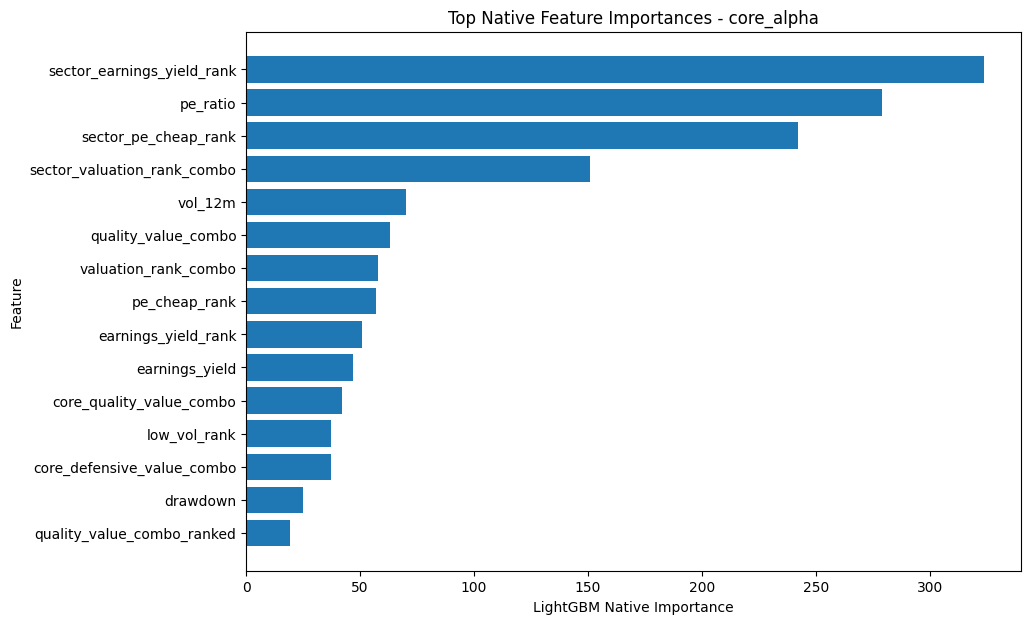

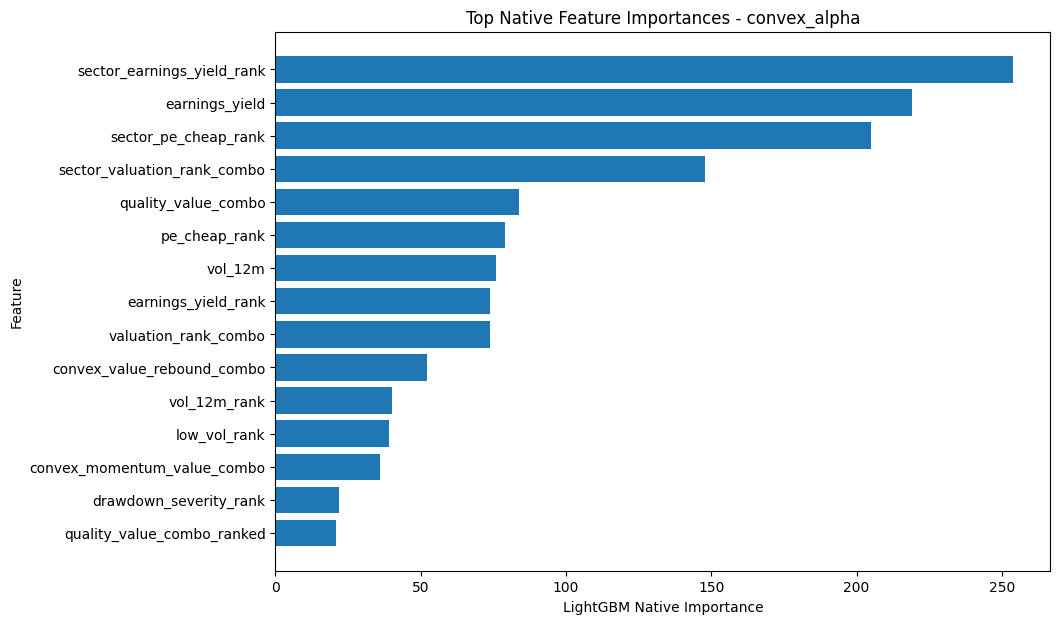

In [15]:
# ======================================
# Plot Top Feature Importances
# ======================================

for portfolio_name in native_importance_v4["portfolio_name"].unique():
    temp = (
        native_importance_v4[
            native_importance_v4["portfolio_name"] == portfolio_name
        ]
        .sort_values("native_importance", ascending=False)
        .head(15)
        .sort_values("native_importance")
    )

    plt.figure(figsize=(10, 7))
    plt.barh(temp["feature"], temp["native_importance"])
    plt.title(f"Top Native Feature Importances - {portfolio_name}")
    plt.xlabel("LightGBM Native Importance")
    plt.ylabel("Feature")
    plt.show()

In [16]:
# ======================================
# Portfolio-Level SHAP Driver Summary
# ======================================

portfolio_driver_summaries = []

for portfolio_name, details in portfolio_shap_details.items():
    summary = (
        details[details["driver_type"] == "positive"]
        .groupby(["portfolio_name", "feature", "feature_label"])
        .agg(
            mean_positive_shap=("shap_value", "mean"),
            total_positive_shap=("shap_value", "sum"),
            num_holdings_driven=("ticker", "nunique"),
        )
        .reset_index()
        .sort_values("total_positive_shap", ascending=False)
    )

    portfolio_driver_summaries.append(summary)

portfolio_driver_summary = pd.concat(
    portfolio_driver_summaries,
    ignore_index=True,
)

portfolio_driver_summary.to_csv(
    INTERPRETABILITY_DIR / "current_portfolio_shap_driver_summary_v4.csv",
    index=False,
)

portfolio_driver_summary

,portfolio_name,feature,feature_label,mean_positive_shap,total_positive_shap,num_holdings_driven
0,core_alpha,vol_12m,12M volatility,0.122089,1.953429,16
1,core_alpha,quality_value_combo,quality/value composite,0.070920,1.205648,17
2,core_alpha,sector_pe_cheap_rank,sector-relative cheap P/E,0.053133,0.318799,6
3,core_alpha,sector_earnings_yield_rank,sector-relative earnings yield,0.071438,0.285754,4
4,core_alpha,pe_ratio,P/E ratio,0.043384,0.260305,6
5,core_alpha,quality_value_combo_ranked,ranked quality/value composite,0.039252,0.157009,4
6,core_alpha,low_vol_rank,low-volatility rank,0.033794,0.101383,3
7,core_alpha,core_defensive_value_combo,Core defensive value composite,0.033389,0.066778,2
8,core_alpha,ret_6m,6M return,0.028095,0.028095,1
9,core_alpha,sector_valuation_rank_combo,sector-relative valuation composite,0.022823,0.022823,1


In [24]:
# ======================================
# Browser-Native Download Links
# ======================================
#
# FileLink can 404 depending on the Jupyter server root / notebook path.
# This creates self-contained browser download links using data URIs.
#
# Works locally in Jupyter because the file content is embedded directly
# into the notebook output link.

from pathlib import Path
from IPython.display import HTML, display
import base64
import mimetypes

def browser_download_link(path, label=None):
    path = Path(path)

    if not path.exists():
        display(HTML(f"<p><b>Missing file:</b> {path}</p>"))
        return

    label = label or path.name

    mime_type, _ = mimetypes.guess_type(path.name)

    if mime_type is None:
        mime_type = "application/octet-stream"

    data = path.read_bytes()
    b64 = base64.b64encode(data).decode("utf-8")

    html = f"""
    <p>
        <b>{label}</b><br>
        <a download="{path.name}"
           href="data:{mime_type};base64,{b64}">
           Download {path.name}
        </a>
    </p>
    """

    display(HTML(html))


print("Download links:")

browser_download_link(CORE_PORTFOLIO_CSV, "Core Alpha Portfolio CSV")
browser_download_link(CONVEX_PORTFOLIO_CSV, "Convex Alpha Portfolio CSV")
browser_download_link(CORE_SHAP_DETAIL_CSV, "Core Alpha SHAP Detail CSV")
browser_download_link(CONVEX_SHAP_DETAIL_CSV, "Convex Alpha SHAP Detail CSV")

if "METHODOLOGY_FILE" in globals():
    browser_download_link(METHODOLOGY_FILE, "Portfolio Methodology Note")

Download links:
